# cuOpt VRP Runnable Comparisons

## Goal

This notebook executes six controlled routing comparisons:

1. One-route thinking to a two-vehicle VRP
2. Basic VRP to CVRP
3. Basic VRP to VRPTW
4. Homogeneous to heterogeneous fleet with eligibility
5. All-required to prize-collecting optional orders
6. A separate pickup-and-delivery problem

The notebook intentionally contains less introductory teaching than `03b`.
Use `04-VRP-Formulation-Extensions.ipynb` for the full feature atlas.

Every comparison is runnable and validated. The scenarios use synthetic teaching data and
are not customer requirements.

## Setup

The shared controls keep runtimes bounded and make the comparisons reproducible.

In [1]:
from pathlib import Path

import cudf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import cuopt
from cuopt import routing

SOLVE_TIME_LIMIT_SEC = 1.0
PRIZE_SOLVE_TIME_LIMIT_SEC = 2.0
PDP_SOLVE_TIME_LIMIT_SEC = 2.0

print(f"cuOpt version: {cuopt.__version__}")

cuOpt version: 26.06.00


## Shared Teaching Data

Comparisons 1–4 use the same depot, eight orders, and two robots. Keeping the data fixed
makes changes in the model easier to interpret.

The order table includes:

- demand for CVRP;
- earliest/latest arrival and service time for VRPTW;
- two specialist orders for the heterogeneous-fleet example;
- prizes for the optional-order example.

In [2]:
shared_orders = pd.DataFrame(
    [
        (0, "A", 1, 100, 100, 4, 0, 5_000, 100, False, 1_000),
        (1, "B", 2, 200, 100, 3, 0, 5_000, 100, False, 1_000),
        (2, "C-special", 3, 300, 100, 4, 0, 5_000, 100, True, 1_000),
        (3, "D", 4, 400, 100, 3, 0, 5_000, 100, False, 1_000),
        (4, "E", 5, 100, 300, 4, 4_500, 10_000, 100, False, 1_000),
        (5, "F", 6, 200, 300, 3, 4_500, 10_000, 100, False, 1_000),
        (6, "G-special", 7, 300, 300, 4, 4_500, 10_000, 100, True, 1_000),
        (7, "H", 8, 400, 300, 3, 4_500, 10_000, 100, False, 1_000),
    ],
    columns=[
        "order_id",
        "label",
        "location_id",
        "x",
        "y",
        "demand",
        "earliest_ms",
        "latest_ms",
        "service_ms",
        "specialist_required",
        "prize",
    ],
)

shared_robots = pd.DataFrame(
    [
        (0, "R-fast", 0, 0, 0, 14, 200.0),
        (1, "R-precise", 1, 0, 0, 14, 100.0),
    ],
    columns=[
        "vehicle_id",
        "robot_id",
        "vehicle_type",
        "start_location",
        "end_location",
        "capacity",
        "speed_units_per_sec",
    ],
)

shared_coordinates = np.vstack(
    [
        np.array([[0.0, 0.0]], dtype=np.float32),
        shared_orders[["x", "y"]].to_numpy(dtype=np.float32),
    ]
)

display(shared_orders)
display(shared_robots)

,order_id,label,location_id,x,y,demand,earliest_ms,latest_ms,service_ms,specialist_required,prize
0,0,A,1,100,100,4,0,5000,100,False,1000
1,1,B,2,200,100,3,0,5000,100,False,1000
2,2,C-special,3,300,100,4,0,5000,100,True,1000
3,3,D,4,400,100,3,0,5000,100,False,1000
4,4,E,5,100,300,4,4500,10000,100,False,1000
5,5,F,6,200,300,3,4500,10000,100,False,1000
6,6,G-special,7,300,300,4,4500,10000,100,True,1000
7,7,H,8,400,300,3,4500,10000,100,False,1000


,vehicle_id,robot_id,vehicle_type,start_location,end_location,capacity,speed_units_per_sec
0,0,R-fast,0,0,0,14,200.0
1,1,R-precise,1,0,0,14,100.0


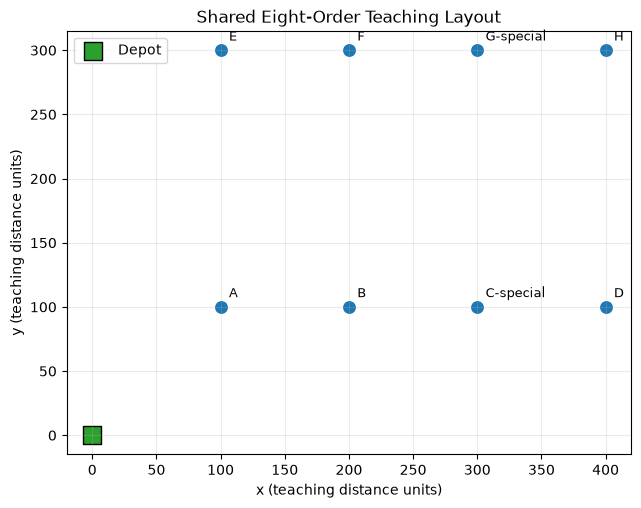

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(
    shared_orders["x"],
    shared_orders["y"],
    s=110,
    color="#1f77b4",
    edgecolor="white",
    linewidth=1.2,
)
ax.scatter(
    0,
    0,
    s=180,
    marker="s",
    color="#2ca02c",
    edgecolor="black",
    label="Depot",
)
for order in shared_orders.itertuples():
    ax.annotate(
        order.label,
        (order.x, order.y),
        xytext=(6, 7),
        textcoords="offset points",
        fontsize=9,
    )
ax.set_title("Shared Eight-Order Teaching Layout")
ax.set_xlabel("x (teaching distance units)")
ax.set_ylabel("y (teaching distance units)")
ax.grid(alpha=0.25)
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

## Shared Helper Functions

These functions keep model construction, solution extraction, and plotting consistent
across scenarios.

In [4]:
def matrix_from_coordinates(coordinates):
    coordinates = np.asarray(coordinates, dtype=np.float32)
    deltas = coordinates[:, None, :] - coordinates[None, :, :]
    return np.sqrt((deltas ** 2).sum(axis=2)).astype(np.float32)


shared_distance_matrix = matrix_from_coordinates(shared_coordinates)
shared_order_locations = shared_orders["location_id"].to_numpy(
    dtype=np.int32
)


def make_settings(seconds):
    settings = routing.SolverSettings()
    settings.set_time_limit(seconds)
    return settings


def build_shared_model(cost_matrix=None):
    active_cost_matrix = (
        shared_distance_matrix
        if cost_matrix is None
        else cost_matrix
    )
    model = routing.DataModel(
        len(shared_coordinates),
        len(shared_robots),
        len(shared_orders),
    )
    model.add_cost_matrix(cudf.DataFrame(active_cost_matrix))
    model.set_order_locations(
        cudf.Series(shared_order_locations, dtype=np.int32)
    )
    model.set_vehicle_locations(
        cudf.Series(
            shared_robots["start_location"],
            dtype=np.int32,
        ),
        cudf.Series(
            shared_robots["end_location"],
            dtype=np.int32,
        ),
    )
    return model


def solve_model(model, seconds):
    solution = routing.Solve(model, make_settings(seconds))
    if solution.get_status() != 0:
        raise RuntimeError(
            f"cuOpt solve failed with status {solution.get_status()}"
        )
    route = solution.get_route().to_pandas().reset_index(drop=True)
    return solution, route


def delivery_order_ids(route):
    return (
        route.loc[route["type"] == "Delivery", "route"]
        .astype(int)
        .tolist()
    )


def starts_and_ends_at_depot(route):
    for _, vehicle_route in route.groupby("truck_id", sort=True):
        if (
            int(vehicle_route.iloc[0]["location"]) != 0
            or int(vehicle_route.iloc[-1]["location"]) != 0
        ):
            return False
    return True


def route_paths(route, label_lookup):
    rows = []
    for vehicle_id, vehicle_route in route.groupby(
        "truck_id", sort=True
    ):
        labels = []
        for row in vehicle_route.itertuples():
            if row.type == "Depot":
                labels.append("DEPOT")
            else:
                labels.append(label_lookup[int(row.route)])
        rows.append(
            {
                "vehicle_id": int(vehicle_id),
                "path": " → ".join(labels),
                "stops": int(
                    (vehicle_route["type"] != "Depot").sum()
                ),
            }
        )
    return pd.DataFrame(rows)


shared_label_lookup = shared_orders.set_index("order_id")[
    "label"
].to_dict()
scenario_records = []
scenario_artifacts = {}


def record_scenario(
    name,
    solution,
    route,
    available_orders,
    objective_units,
    key_change,
    coordinates,
):
    scenario_records.append(
        {
            "scenario": name,
            "vehicles_used": int(solution.get_vehicle_count()),
            "orders_available": int(available_orders),
            "orders_served": int(
                (route["type"] != "Depot").sum()
            ),
            "objective": float(
                solution.get_total_objective()
            ),
            "objective_units": objective_units,
            "key_change": key_change,
        }
    )
    scenario_artifacts[name] = {
        "route": route.copy(),
        "coordinates": np.asarray(coordinates),
    }

## Comparison 1: Basic Two-Vehicle VRP

**Change:** Increase the fleet to two vehicles and request that both be used.

This demonstrates an important cuOpt detail: fleet size is an upper bound unless
`set_min_vehicles()` requests a lower bound.

In [5]:
basic_model = build_shared_model()
basic_model.set_min_vehicles(2)
basic_solution, basic_route = solve_model(
    basic_model,
    SOLVE_TIME_LIMIT_SEC,
)

basic_checks = pd.DataFrame(
    [
        (
            "All eight orders are served",
            sorted(delivery_order_ids(basic_route))
            == list(range(8)),
        ),
        (
            "Exactly two vehicles are used",
            basic_solution.get_vehicle_count() == 2,
        ),
        (
            "Every route starts and ends at the depot",
            starts_and_ends_at_depot(basic_route),
        ),
    ],
    columns=["check", "passed"],
)
display(basic_checks)
if not basic_checks["passed"].all():
    raise AssertionError("Basic VRP validation failed.")

display(route_paths(basic_route, shared_label_lookup))
record_scenario(
    "Basic VRP",
    basic_solution,
    basic_route,
    8,
    "distance units",
    "two vehicles; all orders required",
    shared_coordinates,
)

,check,passed
0,All eight orders are served,True
1,Exactly two vehicles are used,True
2,Every route starts and ends at the depot,True


,vehicle_id,path,stops
0,0,DEPOT → A → DEPOT,1
1,1,DEPOT → E → F → G-special → H → D → C-special ...,7


## Comparison 2: CVRP

**Change:** Add order demand and vehicle capacity.

Total demand is 28 units. Each robot has capacity 14, so the capacity constraint forces
a feasible split across both routes.

In [6]:
cvrp_model = build_shared_model()
cvrp_model.add_capacity_dimension(
    "tool_load",
    cudf.Series(shared_orders["demand"], dtype=np.int32),
    cudf.Series(shared_robots["capacity"], dtype=np.int32),
)
cvrp_solution, cvrp_route = solve_model(
    cvrp_model,
    SOLVE_TIME_LIMIT_SEC,
)

demand_lookup = shared_orders.set_index("order_id")[
    "demand"
].to_dict()
cvrp_load_rows = []
for vehicle_id, vehicle_route in cvrp_route.groupby(
    "truck_id", sort=True
):
    route_demand = sum(
        demand_lookup[order_id]
        for order_id in delivery_order_ids(vehicle_route)
    )
    cvrp_load_rows.append(
        {
            "vehicle_id": int(vehicle_id),
            "route_demand": int(route_demand),
            "capacity": 14,
            "within_capacity": route_demand <= 14,
        }
    )
cvrp_loads = pd.DataFrame(cvrp_load_rows)

display(cvrp_loads)
if (
    sorted(delivery_order_ids(cvrp_route)) != list(range(8))
    or not cvrp_loads["within_capacity"].all()
    or cvrp_loads["route_demand"].sum() != 28
):
    raise AssertionError("CVRP validation failed.")

display(route_paths(cvrp_route, shared_label_lookup))
record_scenario(
    "CVRP",
    cvrp_solution,
    cvrp_route,
    8,
    "distance units",
    "demand and vehicle capacity",
    shared_coordinates,
)

,vehicle_id,route_demand,capacity,within_capacity
0,0,14,14,True
1,1,14,14,True


,vehicle_id,path,stops
0,0,DEPOT → H → G-special → F → E → DEPOT,4
1,1,DEPOT → A → B → C-special → D → DEPOT,4


## Comparison 3: VRPTW

**Change:** Add travel time, order time windows, service times, and vehicle availability.

Orders A–D are early-phase work; E–H are later-phase work. The distance matrix remains
the objective while the transit-time matrix enforces timing.

In [7]:
vrptw_model = build_shared_model()
shared_travel_time_ms = (
    shared_distance_matrix / 200.0 * 1_000.0
).astype(np.float32)
vrptw_model.add_transit_time_matrix(
    cudf.DataFrame(shared_travel_time_ms)
)
vrptw_model.set_order_time_windows(
    cudf.Series(
        shared_orders["earliest_ms"],
        dtype=np.int32,
    ),
    cudf.Series(
        shared_orders["latest_ms"],
        dtype=np.int32,
    ),
)
vrptw_model.set_order_service_times(
    cudf.Series(
        shared_orders["service_ms"],
        dtype=np.int32,
    )
)
vrptw_model.set_vehicle_time_windows(
    cudf.Series([0, 0], dtype=np.int32),
    cudf.Series([10_000, 10_000], dtype=np.int32),
)
vrptw_model.set_min_vehicles(2)

vrptw_solution, vrptw_route = solve_model(
    vrptw_model,
    SOLVE_TIME_LIMIT_SEC,
)

window_lookup = shared_orders.set_index("order_id")[
    ["earliest_ms", "latest_ms"]
].to_dict(orient="index")
vrptw_delivery_rows = vrptw_route.loc[
    vrptw_route["type"] == "Delivery"
].copy()
vrptw_delivery_rows["window_satisfied"] = [
    window_lookup[int(row.route)]["earliest_ms"]
    <= float(row.arrival_stamp)
    <= window_lookup[int(row.route)]["latest_ms"]
    for row in vrptw_delivery_rows.itertuples()
]

display(
    vrptw_delivery_rows[
        [
            "truck_id",
            "route",
            "location",
            "arrival_stamp",
            "window_satisfied",
        ]
    ]
)
if (
    sorted(delivery_order_ids(vrptw_route)) != list(range(8))
    or not vrptw_delivery_rows["window_satisfied"].all()
    or not starts_and_ends_at_depot(vrptw_route)
):
    raise AssertionError("VRPTW validation failed.")

display(route_paths(vrptw_route, shared_label_lookup))
record_scenario(
    "VRPTW",
    vrptw_solution,
    vrptw_route,
    8,
    "distance units",
    "travel time, windows, and service",
    shared_coordinates,
)

,truck_id,route,location,arrival_stamp,window_satisfied
1,1,0,1,707.106750,True
4,0,1,2,1118.034058,True
5,0,2,3,1718.034058,True
6,0,3,4,2318.034058,True
7,0,7,8,4500.000000,True
8,0,6,7,5100.000000,True
9,0,5,6,5700.000000,True
10,0,4,5,6300.000000,True


,vehicle_id,path,stops
0,0,DEPOT → B → C-special → D → H → G-special → F ...,7
1,1,DEPOT → A → DEPOT,1


## Comparison 4: Heterogeneous Fleet and Eligibility

**Change:** Give the two robot types different travel-time costs and restrict specialist
orders C and G to `R-precise`.

Vehicle 0 uses the faster type-0 matrix. Vehicle 1 uses the type-1 matrix and is the only
eligible robot for the specialist operations.

In [8]:
fast_cost_ms = (
    shared_distance_matrix
    / shared_robots.loc[0, "speed_units_per_sec"]
    * 1_000.0
).astype(np.float32)
precise_cost_ms = (
    shared_distance_matrix
    / shared_robots.loc[1, "speed_units_per_sec"]
    * 1_000.0
).astype(np.float32)

heterogeneous_model = routing.DataModel(
    len(shared_coordinates),
    2,
    len(shared_orders),
)
heterogeneous_model.add_cost_matrix(
    cudf.DataFrame(fast_cost_ms),
    0,
)
heterogeneous_model.add_cost_matrix(
    cudf.DataFrame(precise_cost_ms),
    1,
)
heterogeneous_model.set_vehicle_types(
    cudf.Series([0, 1], dtype=np.int32)
)
heterogeneous_model.set_order_locations(
    cudf.Series(shared_order_locations, dtype=np.int32)
)
heterogeneous_model.set_vehicle_locations(
    cudf.Series([0, 0], dtype=np.int32),
    cudf.Series([0, 0], dtype=np.int32),
)
heterogeneous_model.set_min_vehicles(2)

specialist_order_ids = (
    shared_orders.loc[
        shared_orders["specialist_required"],
        "order_id",
    ]
    .astype(int)
    .tolist()
)
for order_id in specialist_order_ids:
    heterogeneous_model.add_order_vehicle_match(
        order_id,
        cudf.Series([1], dtype=np.int32),
    )

heterogeneous_solution, heterogeneous_route = solve_model(
    heterogeneous_model,
    SOLVE_TIME_LIMIT_SEC,
)

specialist_assignments = heterogeneous_route.loc[
    (heterogeneous_route["type"] == "Delivery")
    & heterogeneous_route["route"].isin(specialist_order_ids),
    ["route", "truck_id"],
].copy()
specialist_assignments["assigned_to_precise_robot"] = (
    specialist_assignments["truck_id"] == 1
)

display(specialist_assignments)
if (
    sorted(delivery_order_ids(heterogeneous_route))
    != list(range(8))
    or not specialist_assignments[
        "assigned_to_precise_robot"
    ].all()
):
    raise AssertionError(
        "Heterogeneous-fleet validation failed."
    )

display(
    route_paths(
        heterogeneous_route,
        shared_label_lookup,
    )
)
record_scenario(
    "Heterogeneous VRP",
    heterogeneous_solution,
    heterogeneous_route,
    8,
    "travel-time cost (ms)",
    "vehicle types and specialist eligibility",
    shared_coordinates,
)

,route,truck_id,assigned_to_precise_robot
2,2,1,True
5,6,1,True


,vehicle_id,path,stops
0,0,DEPOT → A → DEPOT,1
1,1,DEPOT → B → C-special → D → H → G-special → F ...,7


## Comparison 5: Prize-Collecting Optional Orders

**Change:** Add a remote ninth order with a low prize and let the objective trade collected
prize against route cost.

The eight nearby orders each have prize 1,000. The remote order has prize 100. With equal
objective weights, the remote order is not worth its added travel cost.

In [9]:
prize_orders = pd.concat(
    [
        shared_orders[
            [
                "order_id",
                "label",
                "location_id",
                "x",
                "y",
                "prize",
            ]
        ],
        pd.DataFrame(
            [
                {
                    "order_id": 8,
                    "label": "Remote-low-value",
                    "location_id": 9,
                    "x": 900,
                    "y": 900,
                    "prize": 100,
                }
            ]
        ),
    ],
    ignore_index=True,
)
prize_coordinates = np.vstack(
    [
        np.array([[0.0, 0.0]], dtype=np.float32),
        prize_orders[["x", "y"]].to_numpy(
            dtype=np.float32
        ),
    ]
)
prize_distance_matrix = matrix_from_coordinates(
    prize_coordinates
)

prize_model = routing.DataModel(
    len(prize_coordinates),
    1,
    len(prize_orders),
)
prize_model.add_cost_matrix(
    cudf.DataFrame(prize_distance_matrix)
)
prize_model.set_order_locations(
    cudf.Series(
        prize_orders["location_id"],
        dtype=np.int32,
    )
)
prize_model.set_vehicle_locations(
    cudf.Series([0], dtype=np.int32),
    cudf.Series([0], dtype=np.int32),
)
prize_model.set_order_prizes(
    cudf.Series(prize_orders["prize"], dtype=np.float32)
)
prize_model.set_objective_function(
    cudf.Series(
        [routing.Objective.PRIZE, routing.Objective.COST],
        dtype=np.int32,
    ),
    cudf.Series([1.0, 1.0], dtype=np.float32),
)

prize_solution, prize_route = solve_model(
    prize_model,
    PRIZE_SOLVE_TIME_LIMIT_SEC,
)
prize_visited_ids = sorted(delivery_order_ids(prize_route))
prize_omitted_ids = sorted(
    set(prize_orders["order_id"]) - set(prize_visited_ids)
)

prize_checks = pd.DataFrame(
    [
        (
            "All eight high-prize orders are served",
            prize_visited_ids == list(range(8)),
        ),
        (
            "The remote low-prize order is omitted",
            prize_omitted_ids == [8],
        ),
        (
            "The route starts and ends at the depot",
            starts_and_ends_at_depot(prize_route),
        ),
    ],
    columns=["check", "passed"],
)
display(prize_checks)
if not prize_checks["passed"].all():
    raise AssertionError("Prize-collecting validation failed.")

prize_label_lookup = prize_orders.set_index("order_id")[
    "label"
].to_dict()
display(route_paths(prize_route, prize_label_lookup))
display(
    pd.DataFrame(
        {
            "visited_order_ids": [prize_visited_ids],
            "omitted_order_ids": [prize_omitted_ids],
        }
    )
)
record_scenario(
    "Prize-collecting VRP",
    prize_solution,
    prize_route,
    9,
    "weighted prize-cost score",
    "optional orders and prize objective",
    prize_coordinates,
)

,check,passed
0,All eight high-prize orders are served,True
1,The remote low-prize order is omitted,True
2,The route starts and ends at the depot,True


,vehicle_id,path,stops
0,0,DEPOT → A → B → C-special → D → H → G-special ...,8


,visited_order_ids,omitted_order_ids
0,"[0, 1, 2, 3, 4, 5, 6, 7]",[8]


## Comparison 6: Pickup and Delivery

**Change:** Use three explicit pickup-delivery pairs with payload capacity.

This comparison uses a separate dataset because the installed cuOpt 26.06 PDP interface
requires all non-depot orders in the model to participate in pairs.

In [10]:
pdp_coordinates = np.array(
    [
        [0, 0],
        [100, 100],
        [100, 300],
        [300, 100],
        [400, 100],
        [400, 300],
        [200, 400],
    ],
    dtype=np.float32,
)
pdp_distance_matrix = matrix_from_coordinates(pdp_coordinates)
pickup_ids = [1, 2, 3]
delivery_ids = [4, 5, 6]
pdp_pair_lookup = dict(zip(pickup_ids, delivery_ids))

pdp_model = routing.DataModel(
    len(pdp_coordinates),
    2,
)
pdp_model.add_cost_matrix(
    cudf.DataFrame(pdp_distance_matrix)
)
pdp_model.set_pickup_delivery_pairs(
    cudf.Series(pickup_ids, dtype=np.int32),
    cudf.Series(delivery_ids, dtype=np.int32),
)
pdp_model.add_capacity_dimension(
    "payload",
    cudf.Series(
        [0, 1, 1, 1, -1, -1, -1],
        dtype=np.int32,
    ),
    cudf.Series([2, 2], dtype=np.int32),
)
pdp_model.set_min_vehicles(2)

pdp_solution, pdp_route = solve_model(
    pdp_model,
    PDP_SOLVE_TIME_LIMIT_SEC,
)

pair_check_rows = []
for pickup_id, delivery_id in pdp_pair_lookup.items():
    pickup_match = pdp_route.loc[
        (pdp_route["route"] == pickup_id)
        & (pdp_route["type"] == "Pickup")
    ]
    delivery_match = pdp_route.loc[
        (pdp_route["route"] == delivery_id)
        & (pdp_route["type"] == "Delivery")
    ]
    same_vehicle = (
        len(pickup_match) == 1
        and len(delivery_match) == 1
        and int(pickup_match.iloc[0]["truck_id"])
        == int(delivery_match.iloc[0]["truck_id"])
    )
    pickup_before_delivery = (
        same_vehicle
        and int(pickup_match.index[0])
        < int(delivery_match.index[0])
    )
    pair_check_rows.append(
        {
            "pickup": pickup_id,
            "delivery": delivery_id,
            "same_vehicle": same_vehicle,
            "pickup_before_delivery": pickup_before_delivery,
        }
    )
pdp_pair_checks = pd.DataFrame(pair_check_rows)

pdp_demands = {
    1: 1,
    2: 1,
    3: 1,
    4: -1,
    5: -1,
    6: -1,
}
pdp_capacity_checks = []
for vehicle_id, vehicle_route in pdp_route.groupby(
    "truck_id", sort=True
):
    load = 0
    load_feasible = True
    for row in vehicle_route.itertuples():
        if row.type == "Depot":
            continue
        load += pdp_demands[int(row.route)]
        load_feasible = load_feasible and 0 <= load <= 2
    pdp_capacity_checks.append(
        {
            "vehicle_id": int(vehicle_id),
            "capacity_feasible": load_feasible,
            "ending_load": load,
        }
    )
pdp_capacity_checks = pd.DataFrame(pdp_capacity_checks)

display(pdp_pair_checks)
display(pdp_capacity_checks)
if (
    not pdp_pair_checks[
        ["same_vehicle", "pickup_before_delivery"]
    ].all().all()
    or not pdp_capacity_checks["capacity_feasible"].all()
    or not (pdp_capacity_checks["ending_load"] == 0).all()
):
    raise AssertionError(
        "Pickup-and-delivery validation failed."
    )

pdp_label_lookup = {
    1: "P1",
    2: "P2",
    3: "P3",
    4: "D1",
    5: "D2",
    6: "D3",
}
display(route_paths(pdp_route, pdp_label_lookup))
record_scenario(
    "Pickup and Delivery",
    pdp_solution,
    pdp_route,
    6,
    "distance units",
    "paired orders and payload capacity",
    pdp_coordinates,
)

,pickup,delivery,same_vehicle,pickup_before_delivery
0,1,4,True,True
1,2,5,True,True
2,3,6,True,True


,vehicle_id,capacity_feasible,ending_load
0,0,True,0
1,1,True,0


,vehicle_id,path,stops
0,0,DEPOT → P1 → D1 → DEPOT,2
1,1,DEPOT → P3 → P2 → D3 → D2 → DEPOT,4


## Side-by-Side Result Table

Objective values with different units are not directly comparable. The useful comparison
is how each feature changes feasibility, fleet use, order coverage, and route structure.

In [11]:
scenario_comparison = pd.DataFrame(scenario_records)
display(
    scenario_comparison[
        [
            "scenario",
            "vehicles_used",
            "orders_available",
            "orders_served",
            "objective",
            "objective_units",
            "key_change",
        ]
    ].round(2)
)

if len(scenario_comparison) != 6:
    raise AssertionError("Expected six completed scenarios.")

,scenario,vehicles_used,orders_available,orders_served,objective,objective_units,key_change
0,Basic VRP,2,8,8,1522.68,distance units,two vehicles; all orders required
1,CVRP,2,8,8,1969.96,distance units,demand and vehicle capacity
2,VRPTW,2,8,8,1522.68,distance units,"travel time, windows, and service"
3,Heterogeneous VRP,2,8,8,13812.56,travel-time cost (ms),vehicle types and specialist eligibility
4,Prize-collecting VRP,1,9,8,-6742.35,weighted prize-cost score,optional orders and prize objective
5,Pickup and Delivery,2,6,6,2317.83,distance units,paired orders and payload capacity


## Route Gallery

Each panel shows the executed cuOpt route. Colors identify vehicles; the green square is
the depot. The prize scenario includes the omitted remote point in blue without a route
segment.

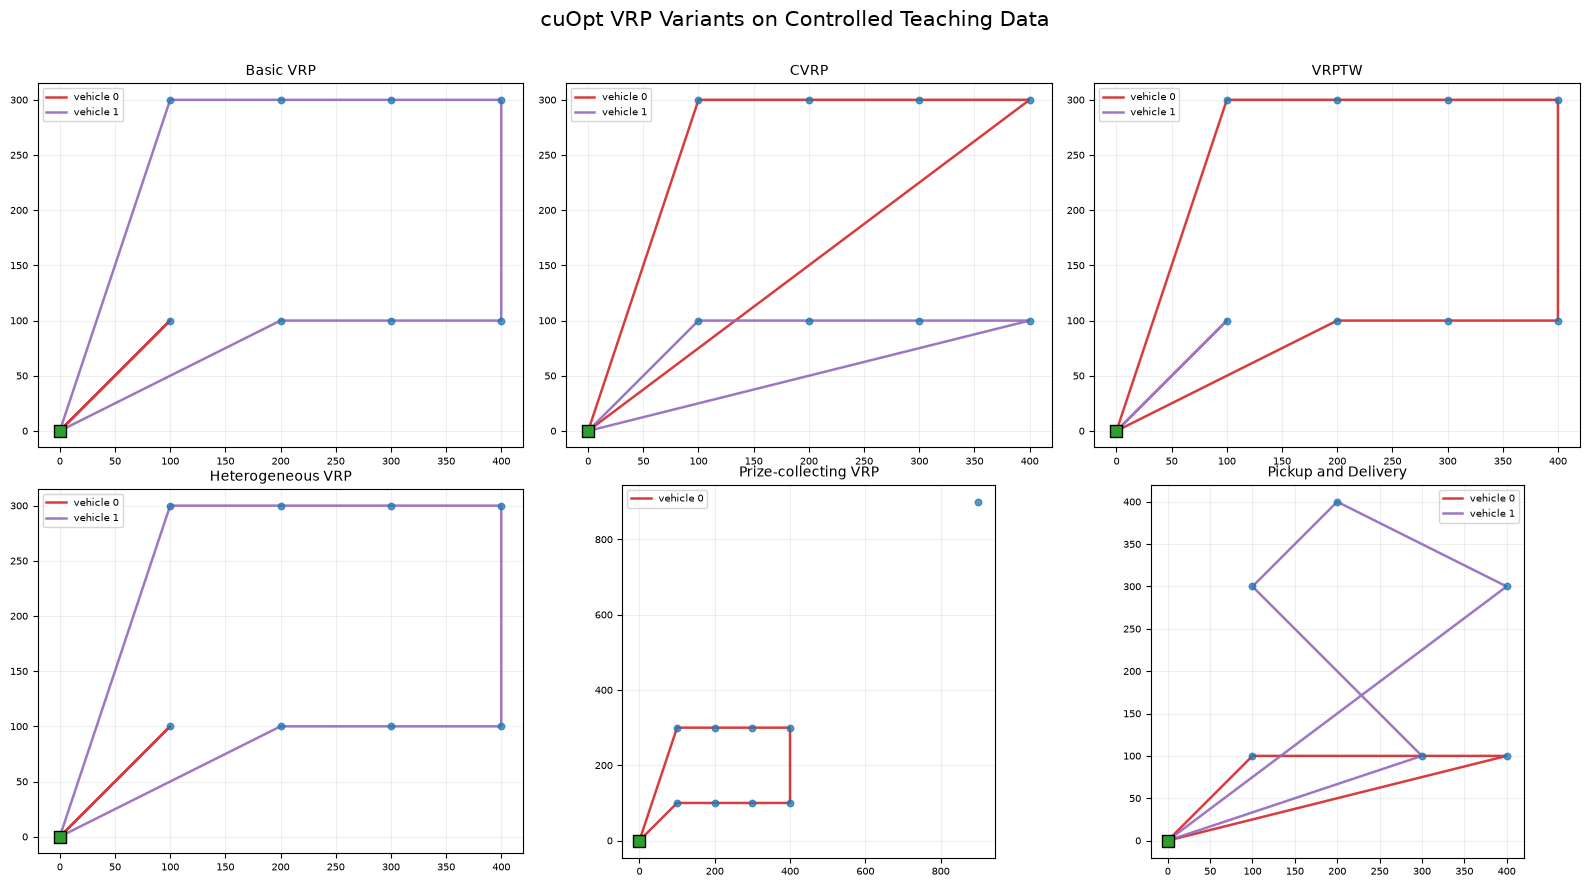

In [12]:
def plot_artifact(ax, artifact, title):
    route = artifact["route"]
    coordinates = artifact["coordinates"]
    colors = ["#d62728", "#9467bd", "#ff7f0e", "#17becf"]

    ax.scatter(
        coordinates[1:, 0],
        coordinates[1:, 1],
        s=22,
        color="#1f77b4",
        alpha=0.75,
        zorder=3,
    )
    ax.scatter(
        coordinates[0, 0],
        coordinates[0, 1],
        s=80,
        marker="s",
        color="#2ca02c",
        edgecolor="black",
        zorder=4,
    )

    for vehicle_id, vehicle_route in route.groupby(
        "truck_id", sort=True
    ):
        location_sequence = (
            vehicle_route["location"].astype(int).to_numpy()
        )
        route_xy = coordinates[location_sequence]
        ax.plot(
            route_xy[:, 0],
            route_xy[:, 1],
            color=colors[int(vehicle_id) % len(colors)],
            linewidth=1.8,
            alpha=0.9,
            label=f"vehicle {int(vehicle_id)}",
        )

    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.2)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc="best")


figure, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, scenario_name in zip(
    axes.flat,
    [
        "Basic VRP",
        "CVRP",
        "VRPTW",
        "Heterogeneous VRP",
        "Prize-collecting VRP",
        "Pickup and Delivery",
    ],
):
    plot_artifact(
        ax,
        scenario_artifacts[scenario_name],
        scenario_name,
    )

figure.suptitle(
    "cuOpt VRP Variants on Controlled Teaching Data",
    fontsize=15,
)
figure.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## What Changed in Each Comparison?

| Scenario | Data | Constraint | Objective | Problem family |
| --- | --- | --- | --- | --- |
| Basic VRP | two vehicles | minimum fleet use | distance | VRP |
| CVRP | demand and capacity | route load | distance | CVRP |
| VRPTW | transit time, windows, service | timing | distance | VRPTW |
| Heterogeneous VRP | vehicle types and matrices | eligibility | travel-time cost | heterogeneous VRP |
| Prize collecting | prizes and remote order | orders may be omitted | prize plus cost | prize-collecting VRP |
| Pickup and delivery | paired nodes and signed demand | pairing, order, capacity | distance | PDP |

## Takeaways

1. Named VRP variants are combinations of reusable routing features.
2. Full comparisons are clearest when one controlled dataset is reused.
3. Capacity, time, eligibility, and optional work change different parts of the model.
4. Objective values cannot be compared without respecting their units and weights.
5. Pickup and delivery deserves a separate micro-example because its data contract differs
   from ordinary orders in the installed 26.06 API.

Use `04-VRP-Formulation-Extensions.ipynb` for the broader feature menu and the
routing-to-MIP boundary.